<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 4: Análisis de datasets
        </td>
    </tr>
    <tr>
 

</table>

## Ejercicio 1

Con este ejercicio se practicará con el cargado de los datos a través de una fuente externa
(una url) y algunas de las funciones básicas del paquete pandas.

a) Crear un script que cargue la última versión del dataset California housing que se
encuentra en:

https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv

b)Mostrar las 7 primeras observaciones de la base descargada.

c) Describir la base de datos (número y tipo de las variables que la conforman y si
existen datos faltantes en algunas de las variables).

Solución

a) El primer paso a realizar cuando trabajamos en Python es cargar los paquetes y
funciones que se van a utilizar (recordar que deben haberse instalado previamente).
Una vez cargadas las librerías, se crea un script que carga la última versión del
dataset California housing accediendo al repositorio de github donde se encuentra
el contenido. Primero, se define una función que descargue los datos y los descomprima
en csv (están comprimidos en .tgz). Después, se define otra función que
cargue estos datos en un dataframe.

In [1]:
#Librerias que se van a necesitar
import os
import tarfile
import urllib.request
import pandas as pd

#Definir las rutas y caminos donde se encuentran los datos
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"

#Ruta que se va a crear en nuestro sistema
HOUSING_PATH = os.path.join("datasets", "housing")

# lugar de descarga del dataset
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL,housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()


fetch_housing_data()

#Definir una funcion que cargue el csv en un dataframe----------
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)
    
housing = load_housing_data()
housing

C:\Users\Michelle Jiménez\AppData\Local\Temp\ipykernel_13064\1682401407.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [2]:
#Se muestra el dataframe


b) Con el método .head(7) se muestran las primeras 7 observaciones

In [3]:
housing.head(7)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


c) Para describir la base de datos se utiliza el método .info(), el cual va a indicar el
número y tipo de las variables que conforman el dataset, así como el número de
observaciones no nulas para cada variable

In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Ejercicio 2

a) En la base de datos California housing existe una variable que no es del tipo numérico.
Mostrar los diferentes valores que toma dicha variable.

b) Describir las variables numéricas (máximo, mínimo, media, desviación típica, cuartiles,
etc.) y realizar un histograma de cada una de ellas..

### Solución

a) Para obtener los diferentes valores de una variable se debe seleccionar la variable
de interés y se puede emplear el método .value_counts().

In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

b) Para obtener un buen descriptivo de las variables numéricas se emplea el método .describe()

In [8]:
#Descriptivo de la base de datos
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Para dibujar los histogramas de las variables numéricas se puede emplear el método
.hist(), donde se el número de barras que aparece en el histograma se define con el
argumento bins.

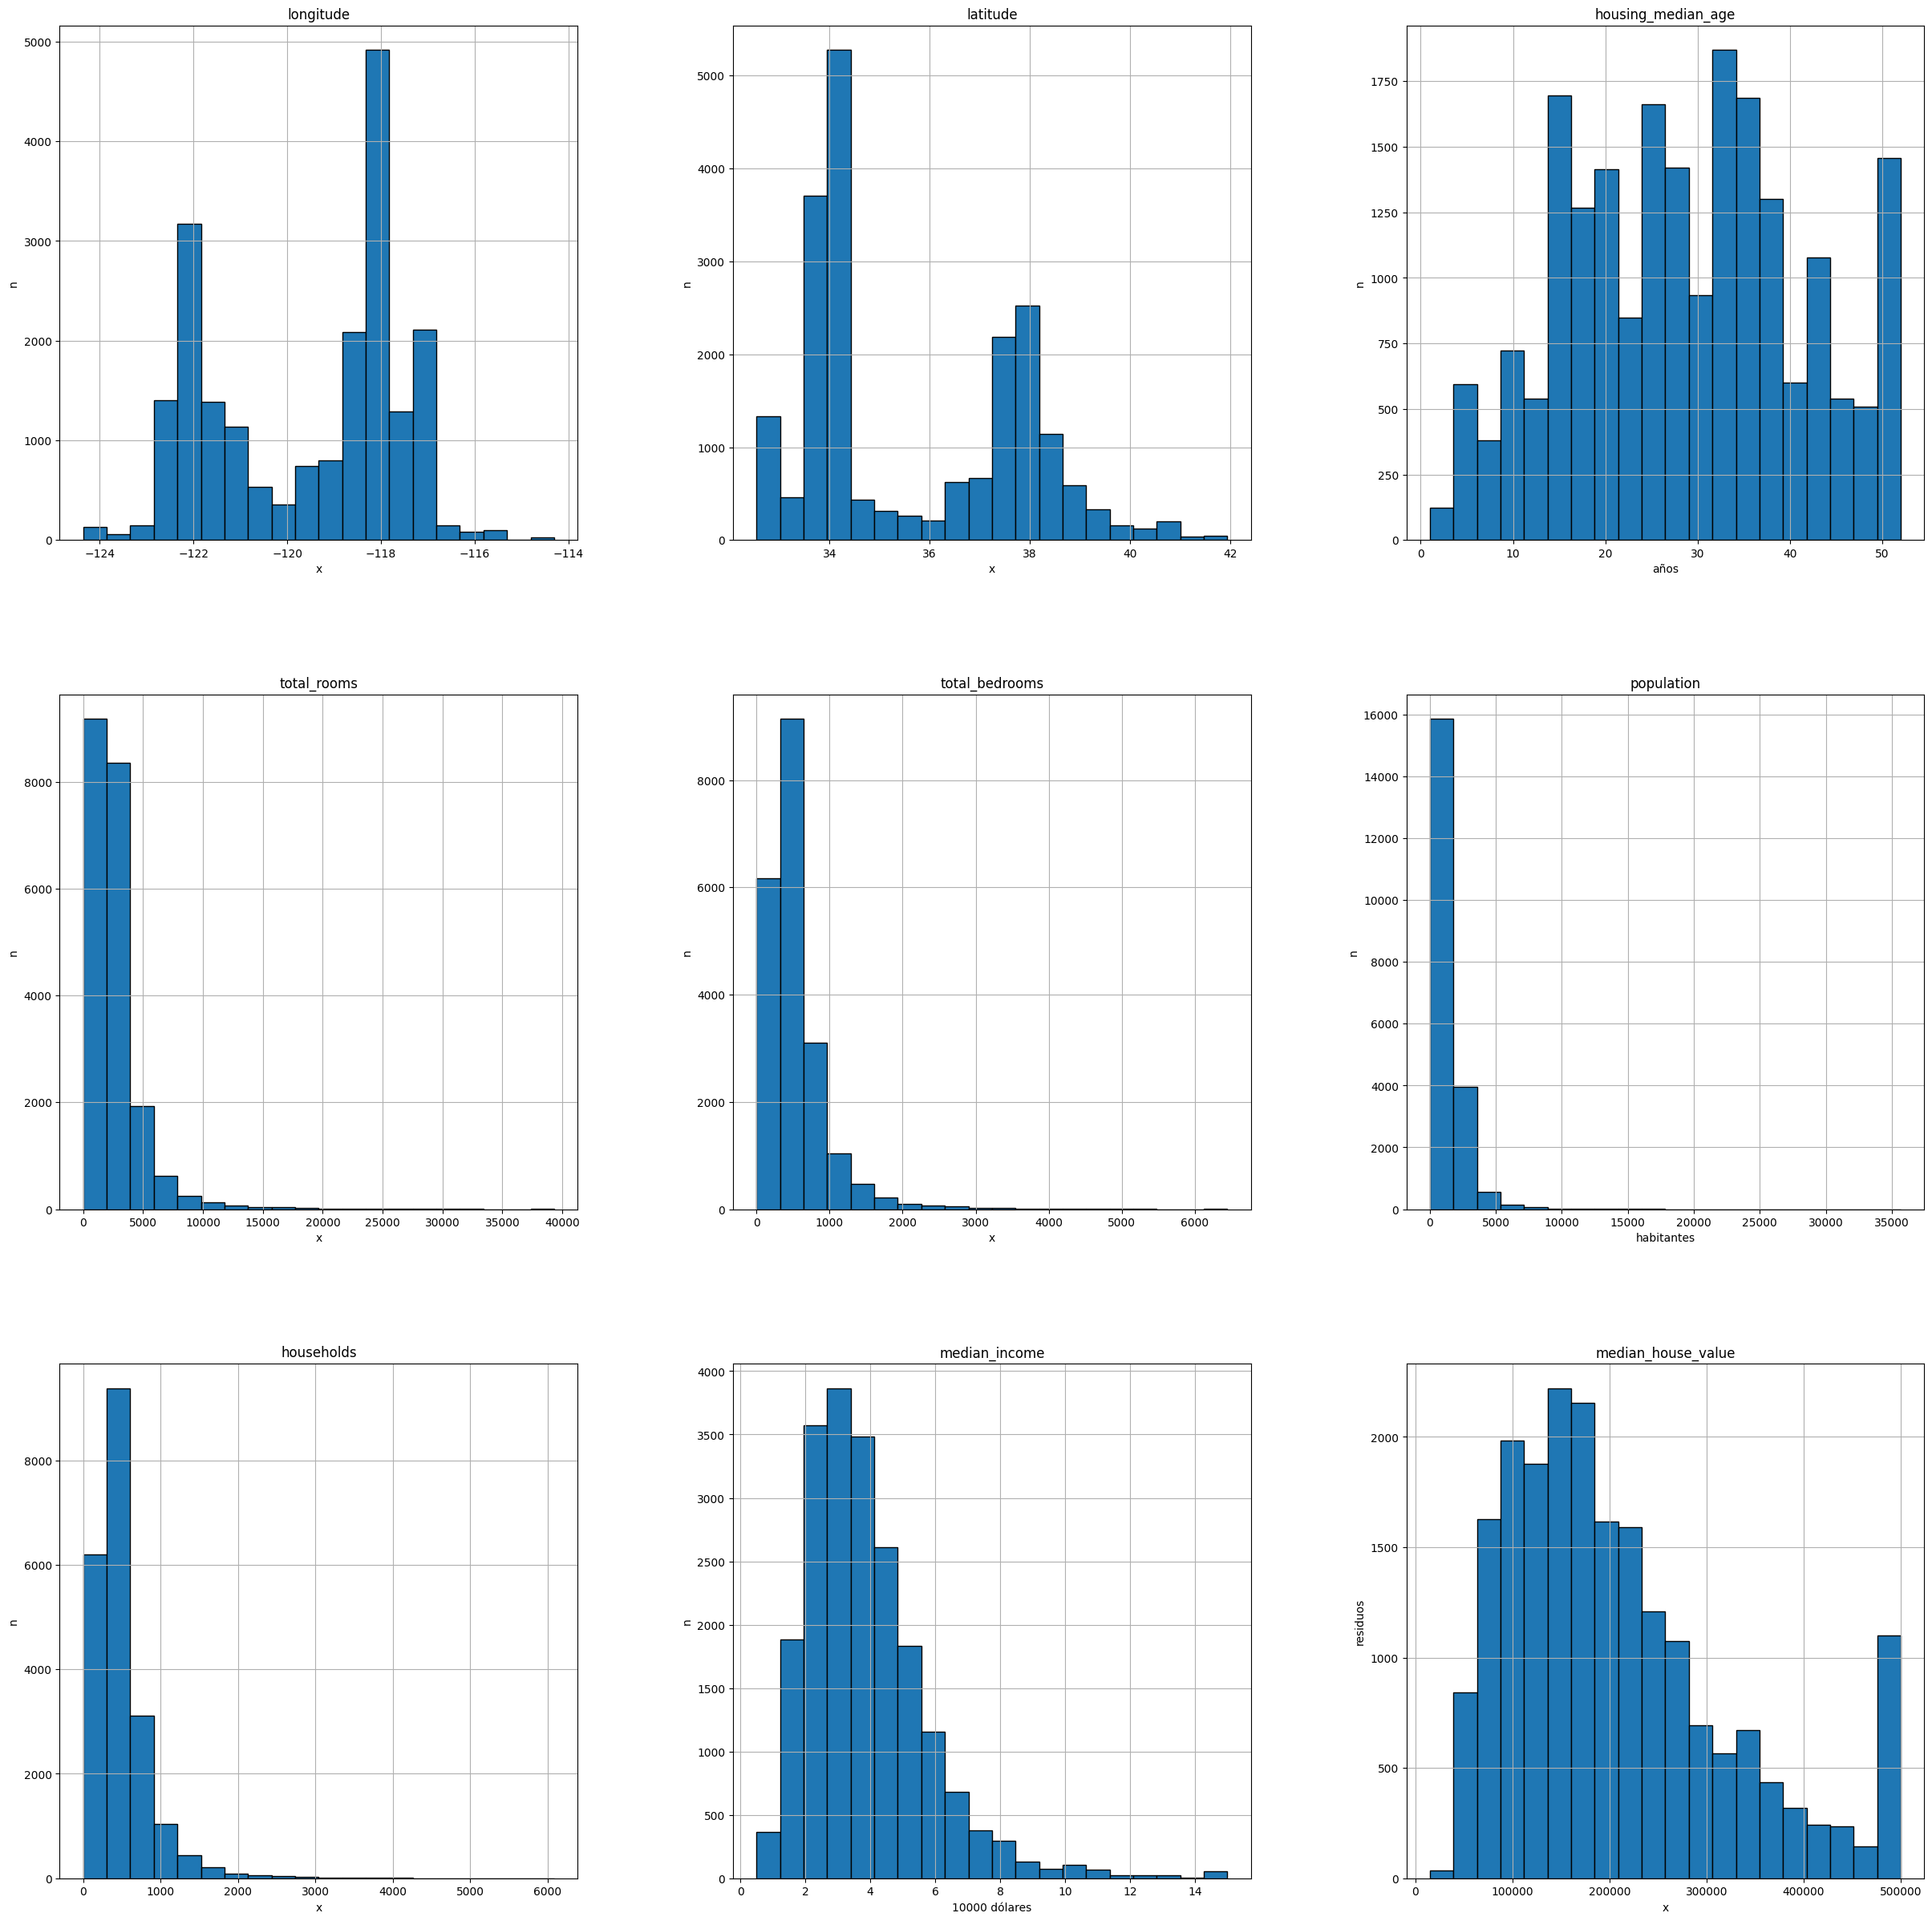

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

#Dividir los histogramas numerico
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (30,30))

#Definir nombres ejes
#Primera fila
axes[0,0].set_xlabel("x")
axes[0,0].set_ylabel("n")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("n")
axes[0,2].set_xlabel("años")
axes[0,2].set_ylabel("n")

#Segunda fila
axes[1,0].set_xlabel("x")
axes[1,0].set_ylabel("n")
axes[1,1].set_xlabel("x")
axes[1,1].set_ylabel("n")
axes[1,2].set_xlabel("habitantes")
axes[1,2].set_ylabel("n")

#Tercera fila
axes[2,0].set_xlabel("x")
axes[2,0].set_ylabel("n")
axes[2,1].set_xlabel("10000 dólares")
axes[2,1].set_ylabel("n")
axes[2,2].set_xlabel("dólares")
axes[2,2].set_ylabel("n")
housing.hist(bins = 20, ax = axes,edgecolor="Black");
plt.xlabel("x");
plt.ylabel("residuos");
plt.show();

## Ejercicio 3

a) Dividir el dataset California housing en un dataset de entrenamiento 0.7 y en un dataset de test 0.3.

b) Divide el dataset de California housing en 10 particiones listas para poder realizar validación cruzada

### Solución 

a) Para poder obtener el error de generalización de un algoritmo de aprendizaje automático
es necesario emplear alguna técnica de validación. Una de las más sencillas
consiste en dividir el conjunto de datos en dataset de entrenamiento y de test

Para dividir el conjunto de datos en las particiones de entrenamiento y de test en
python se define la función particiones con argumentos el conjunto de datos sobre el
cual se van a realizar las particiones y la proporción destinada a la partición de test
(dataset, test_part). En está función se obtiene el entero más cercano del resultado
de multiplicar el número de observaciones del conjunto de datos por la proporción
destinada para el test (test_part_size). Por otro lado, se barajan los índices del dataset
de manera aleatoria usando la función np.random.permutation. Por último, se asignan
los test_part_size índices a test_indices y los índices restantes a train_indices.

In [10]:
#Definir semilla para que la particion sea la misma
np.random.seed(3)

#Definir funcion particiones
def particiones(dataset, test_part):
    test_part_size = int(len(dataset) * test_part)
    mezclar_indices = np.random.permutation(len(dataset))
    test_indices = mezclar_indices[:test_part_size]
    train_indices = mezclar_indices[test_part_size:]
    return dataset.iloc[train_indices], dataset.iloc[test_indices]
    
#Usar funcion particiones con test_part 0.3
train_set, test_set = particiones(housing, 0.3)

In [12]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
215,-122.22,37.79,38.0,3049.0,711.0,2167.0,659.0,2.7969,141700.0,NEAR BAY
1241,-121.91,39.03,48.0,1096.0,218.0,657.0,199.0,2.7841,65800.0,INLAND
4922,-118.25,34.00,41.0,1768.0,475.0,1721.0,474.0,1.3030,90400.0,<1H OCEAN
4852,-118.31,34.03,47.0,1315.0,NaN,785.0,245.0,1.2300,138400.0,<1H OCEAN
17711,-121.81,37.33,4.0,5532.0,778.0,3651.0,770.0,7.2982,343000.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
6400,-118.05,34.13,23.0,3264.0,729.0,1475.0,668.0,3.7350,218300.0,INLAND
15288,-117.31,33.10,15.0,2392.0,446.0,747.0,421.0,3.5341,500001.0,NEAR OCEAN
11513,-118.07,33.72,24.0,1240.0,296.0,513.0,254.0,4.9044,485000.0,NEAR OCEAN
1688,-122.27,37.98,23.0,3455.0,479.0,1375.0,474.0,6.0289,218600.0,NEAR BAY


In [11]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9491,-123.19,39.21,22.0,1542.0,291.0,821.0,285.0,3.5917,118800.0,<1H OCEAN
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,INLAND
11271,-117.99,33.79,21.0,2695.0,707.0,1888.0,683.0,3.2857,213300.0,<1H OCEAN
19219,-122.67,38.47,19.0,1848.0,428.0,1130.0,433.0,3.0568,190300.0,<1H OCEAN
14356,-117.23,32.75,11.0,4304.0,1245.0,1960.0,1105.0,3.3456,159800.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
10112,-117.94,33.94,30.0,1596.0,307.0,845.0,309.0,4.5096,241100.0,<1H OCEAN
19029,-122.01,38.36,28.0,1967.0,315.0,734.0,291.0,4.9583,146200.0,INLAND
11085,-117.89,33.84,35.0,3315.0,744.0,2425.0,687.0,3.5521,182800.0,<1H OCEAN
16200,-121.27,37.95,52.0,1318.0,308.0,1368.0,310.0,1.8261,54600.0,INLAND


b) Para dividir el conjunto de datos en 10 particiones se procede de manera similar,
pero en este caso se va a emplear un bucle con el número de particiones y se va a
definir cada partición en la lista part_cv.

In [13]:
#Definir numero de particiones
n = 10
#Crear lista del 1 al 10
n_list = list(range(1,n+1))
#Definir longitud de cada particion
part_size = int(len(housing) / n)

#Barajar índices
mezclar_indices = np.random.permutation(len(housing))
#Crear lista vacia
part_cv = {}

#Asignar conjunto de indices
for i in n_list:
  part_i = mezclar_indices[part_size * (i-1):part_size * i]
  part_cv["part_{0}".format(i)] = housing.iloc[part_i]

In [14]:
part_cv["part_1"]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
11943,-117.43,33.95,36.0,2284.0,444.0,1425.0,405.0,4.0526,104500.0,INLAND
19142,-122.69,38.32,15.0,2536.0,414.0,1400.0,426.0,5.6613,172400.0,<1H OCEAN
17024,-122.31,37.50,22.0,14034.0,3020.0,6266.0,2952.0,4.3939,491200.0,NEAR OCEAN
6275,-117.93,34.01,23.0,3188.0,836.0,3883.0,840.0,2.1863,157600.0,<1H OCEAN
17937,-121.94,37.34,42.0,2174.0,420.0,1304.0,464.0,3.1429,286500.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
7800,-118.09,33.90,37.0,1147.0,258.0,742.0,242.0,4.0461,153500.0,<1H OCEAN
10179,-117.96,33.86,35.0,2181.0,371.0,1249.0,358.0,4.2937,183200.0,<1H OCEAN
18762,-122.25,40.66,15.0,2771.0,546.0,1423.0,505.0,3.6413,108500.0,INLAND
16737,-122.41,37.70,23.0,1817.0,400.0,1376.0,382.0,2.4113,214200.0,NEAR BAY


## Ejercicio 3

- Dado que hay información geográfica (latitud y longitud), crear un diagrama de dispersión de todos los distritos para visualizar los datos

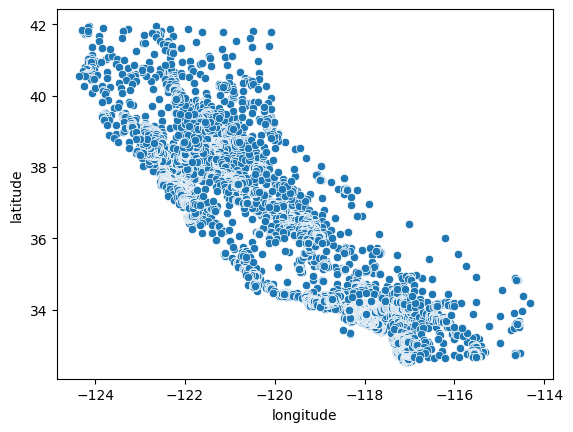

In [19]:
import seaborn as sns
plt.figure()
sns.scatterplot(data= housing, x="longitude", y="latitude")
plt.show()

Esto claramente parece California, pero aparte de eso es difícil identificar algún patrón en particular. Al establecer la opción alpha en 0.1, resulta mucho más fácil visualizar los lugares donde hay una alta densidad de puntos de datos.

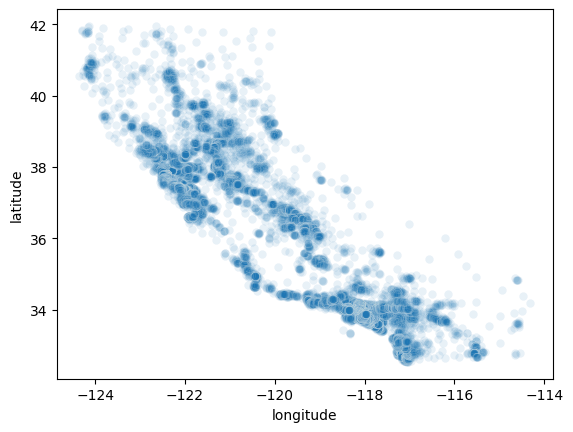

In [17]:
import seaborn as sns
plt.figure()
sns.scatterplot(data= housing, x="longitude", y="latitude", alpha=0.1)
plt.show()

Ahora la visualización es mucho más clara, se pueden identificar fácilmente las zonas de alta densidad

A continuación, se analizan los precios de las viviendas. El radio de cada círculo representa la población del distrito (opción s), mientras que el color representa el precio (opción c). Para este análisis, se utiliza un mapa de colores predefinido.

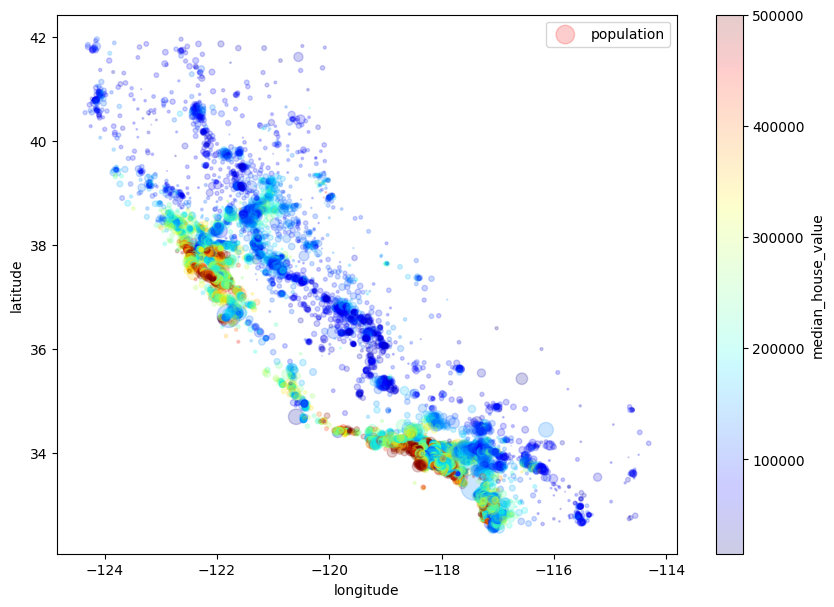

In [20]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

Esta imagen muestra que los precios de las viviendas están estrechamente relacionados con la ubicación geográfica (por ejemplo, la cercanía al océano) y con la densidad poblacional, como era previsible.

En este contexto, un algoritmo de agrupamiento puede resultar útil para identificar los principales conglomerados y para generar nuevas características que midan la proximidad a los centros de dichos grupos.

Asimismo, el atributo de proximidad al océano puede ser relevante; sin embargo, en el norte de California los precios de las viviendas en distritos costeros no son particularmente elevados, por lo que no se trata de una regla simple.